# Energy Calibration

Adjusts SISEPUEDE energy inputs so that model outputs match IEA World Energy Balance targets at a chosen historical reference year.

**What this notebook does, step by step:**
1. Set up models and load inputs
2. Load IEA data and the SISEPUEDE↔IEA crosswalk
3. Measure baseline error (model vs IEA *before* calibration)
4. Build a `CalibrationPlan` — the map of which input variables are knobs for which IEA targets
5. Run the `Calibrator` (two-phase: sector totals, then fuel mix)
6. Measure post-calibration error and compare before vs. after
7. Save the calibrated input file

**Two-phase calibration logic (brief):**
- *Phase 1 — Sector totals:* scales `consumpinit_*`, `scalar_*`, and efficiency variables so that total sector energy (INDUSTRY, TRANSPORT, RESIDENT, COMMPUB) matches IEA. One model run for the whole phase.
- *Phase 2 — Fuel mix:* adjusts `frac_*` fuel-fraction variables so that the share of each fuel within a sector matches IEA. Simplex constraint (fracs sum to 1) is enforced via Aitchison renormalization. One model run for the whole phase.
- Iterating 2× handles residual coupling between the two phases.

---
## 1. Setup — imports and paths

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import sys
path = "/Users/dianamendez/feature-energy-calibration"
if path not in sys.path:
    sys.path.insert(0, path)
    
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sisepuede.manager.sisepuede_file_structure          import SISEPUEDEFileStructure
from sisepuede.calibration.iea_crosswalk                 import IEACrosswalk
from sisepuede.calibration.iea_data_loader               import IEADataLoader
from sisepuede.calibration.build_iea_energy_crosswalk    import IEACrosswalkBuilder
from sisepuede.calibration.build_energy_calibration_plan import build_energy_calibration_plan
from sisepuede.calibration.calibrator                    import Calibrator

# ── Paths — edit these ────────────────────────────────────────────────────────
PATH_SISEPUEDE_INPUT = "/Users/dianamendez/sisepuede-data/input_data_peru_base.csv"
PATH_IEA_DATA_DIR    = "/Users/dianamendez/data_collection_temporary"
PATH_CROSSWALK_FILE  = "/Users/dianamendez/feature-energy-calibration/sisepuede/ref/data_crosswalks/sisepuede_iea_energy_crosswalk.csv"
PATH_OUTPUT_DIR      = "/Users/dianamendez/sisepuede-data"

ISO_COUNTRY          = "PER"
START_YEAR           = 2015   # first year of the comparison window
IEA_YEAR_LIMIT       = 2022   # last year of actual IEA data (rows beyond are projections)
YEAR_TARGET          = 2018   # reference year to calibrate to
N_ITER               = 2      # calibration iterations
N_OPT                = 3      # calibration option: 0 = Phase 1 + Phase 2, 1 = Phase 1 only, 2 = Phase 2 only    
# ─────────────────────────────────────────────────────────────────────────────

file_struct      = SISEPUEDEFileStructure()
model_attributes = file_struct.model_attributes
print("model_attributes loaded")

model_attributes loaded


---
## 2. Build models and run upstream sectors

`EnergyConsumption` depends on outputs from `AFOLU` and `IPPU` (livestock populations, crop production, industrial production, etc.). We run those two first and merge their outputs into the input DataFrame before touching energy.

In [ ]:
from sisepuede.models.afolu              import AFOLU
from sisepuede.models.energy_consumption import EnergyConsumption
from sisepuede.models.ippu               import IPPU

model_afolu     = AFOLU            (model_attributes)
model_ippu      = IPPU             (model_attributes)
model_energycon = EnergyConsumption(model_attributes)

# Load input CSV and attach calendar years
df_input = pd.read_csv(PATH_SISEPUEDE_INPUT)
df_input["year"] = range(START_YEAR, START_YEAR + len(df_input))
col = df_input.pop("year")
df_input.insert(0, "year", col)

# Restrict to rows with actual observed data
df_input = df_input.loc[df_input["year"] <= IEA_YEAR_LIMIT].reset_index(drop=True)
print(f"Input shape: {df_input.shape}  |  years: {df_input['year'].min()}–{df_input['year'].max()}")

Input shape: (8, 2420)  |  years: 2015–2022


In [3]:
# Run AFOLU and IPPU; merge their outputs so EnergyConsumption can use them
df_out_afolu = model_afolu(df_input)
df_out_ippu  = model_ippu (df_input)

df_input_energy = (
    df_input
    .merge(df_out_afolu, on="time_period", how="left", suffixes=("", "_afolu"))
    .merge(df_out_ippu,  on="time_period", how="left", suffixes=("", "_ippu"))
)

print(f"df_input_energy shape: {df_input_energy.shape}")
print(f"Columns with energy inputs (sample):")
print([c for c in df_input_energy.columns if c.startswith("consumpinit_inen")][:5])

df_input_energy shape: (8, 3075)
Columns with energy inputs (sample):
['consumpinit_inen_energy_tj_per_mmm_gdp_other_product_manufacturing', 'consumpinit_inen_energy_tj_per_tonne_production_cement', 'consumpinit_inen_energy_tj_per_tonne_production_chemicals', 'consumpinit_inen_energy_tj_per_tonne_production_electronics', 'consumpinit_inen_energy_tj_per_tonne_production_glass']


In [4]:
# ── Fill NaN values in df_input_energy ───────────────────────────────────────
# After the AFOLU/IPPU left-merge, some columns can be NaN. Inside project(),
# model_socioeconomic.project() also adds columns that may be NaN for certain
# time periods. Either way, check_projection_input_df() calls df.interpolate()
# when any NaN exists, which interpolates each frac column independently and
# can push a row's frac sum above 1.
#
# We fill NaN here so the input is clean going in. The model-level fix that
# makes this robust regardless of NaN is in energy_consumption.py ~line 3743:
#     force_sum_equality = True   (changed from False)
# That makes project_transportation() renormalize fracs internally instead of
# raising ValueError, so floating-point drift from interpolation never crashes.

df_input_energy = df_input_energy.copy()

nan_before = df_input_energy.isna().sum().sum()
if nan_before:
    df_input_energy = df_input_energy.ffill().bfill().fillna(0.0)
    print(f"Filled {nan_before} NaN values in df_input_energy.")
else:
    print("No NaN values found — df_input_energy is clean.")

No NaN values found — df_input_energy is clean.


---
## 3. Load IEA data and build the crosswalk

The crosswalk maps each IEA `(balance_code, product_code)` pair to the SISEPUEDE output column(s) that represent the same quantity. It is used both for evaluating error and for the calibrator to know which output fields to target.

In [5]:
# Build (or refresh) the crosswalk CSV, then load it
builder = IEACrosswalkBuilder(model_attributes, PATH_CROSSWALK_FILE)
builder.build(write_csv=True)

xw = IEACrosswalk(model_attributes, path_crosswalk=PATH_CROSSWALK_FILE)
print(f"Crosswalk loaded: {len(xw.df_crosswalk)} mappable (balance, product) pairs")

IEA crosswalk written to: /Users/dianamendez/feature-energy-calibration/sisepuede/ref/data_crosswalks/sisepuede_iea_energy_crosswalk.csv
Crosswalk loaded: 51 mappable (balance, product) pairs


In [6]:
loader     = IEADataLoader(PATH_IEA_DATA_DIR, model_attributes)
df_iea_raw = loader.load_country(ISO_COUNTRY)

print(f"IEA rows loaded : {len(df_iea_raw)}")
print(f"Years covered   : {df_iea_raw['year'].min()} – {df_iea_raw['year'].max()}")
print(f"\n(balance, product) pairs available:")
print(
    df_iea_raw[["iea_balance_code", "iea_product_code"]]
    .drop_duplicates()
    .sort_values(["iea_balance_code", "iea_product_code"])
    .to_string(index=False)
)

IEA rows loaded : 970
Years covered   : 2000 – 2022

(balance, product) pairs available:
iea_balance_code iea_product_code
        AGRICULT         AGRICULT
     COALEXPORTS          EXPORTS
     COALIMPORTS          IMPORTS
         COMMPUB         BIOWASTE
         COMMPUB             COAL
         COMMPUB          COMMPUB
         COMMPUB           ELECTR
         COMMPUB         GEOTHERM
         COMMPUB           NATGAS
         COMMPUB              OIL
        ELECTOUT          BIOFUEL
        ELECTOUT             COAL
        ELECTOUT            HYDRO
        ELECTOUT           NATGAS
        ELECTOUT              OIL
        ELECTOUT          SOLARPV
        ELECTOUT             WIND
       ELEXPORTS          EXPORTS
       ELIMPORTS          IMPORTS
         EXPORTS          EXPORTS
      GASEXPORTS          EXPORTS
         IMPORTS          IMPORTS
         INDPROD         BIOWASTE
         INDPROD             COAL
         INDPROD         GEOTHERM
         INDPROD           

---
## 4. Baseline error — model vs. IEA *before* calibration

We run the energy model once on the unmodified inputs, aggregate the outputs through the crosswalk, and compare to IEA.

Key column in the comparison table:
- `ratio` — 1.0 = perfect; >1 = model over-estimates; <1 = under-estimates
- `rel_err` — `(model − iea) / iea`; the relative error of the model against IEA

In [ ]:
# Run energy model on unmodified inputs
print("Running baseline model...", end=" ", flush=True)
df_out_baseline = model_energycon(df_input_energy)
df_out_baseline = df_out_baseline.merge(
    df_input_energy[["time_period", "year"]].drop_duplicates(),
    on="time_period", how="left",
)
print("done")

# Aggregate SISEPUEDE outputs to IEA (balance, product) pairs
df_ssp_baseline = xw.aggregate_sisepuede(df_out_baseline, col_year="year")

# Join with IEA data
df_comp_baseline = xw.build_comparison(
    df_ssp_baseline, df_iea_raw,
    year_min=START_YEAR, year_max=IEA_YEAR_LIMIT,
)

print(f"Comparison table: {df_comp_baseline.shape[0]} rows, "
      f"{df_comp_baseline[['iea_balance_code','iea_product_code']].drop_duplicates().shape[0]} unique (balance, product) pairs")

Running baseline model... done
Comparison table: 401 rows, 51 unique (balance, product) pairs


In [ ]:
# Summary — one row per (balance, product), mean ratio over all years
# Rows far from ratio=1 are the highest-priority calibration targets
df_summary_baseline = xw.summary(df_comp_baseline)

# Filter to pairs where both IEA and SISEPUEDE data exist
df_summary_baseline_matched = df_summary_baseline[
    df_summary_baseline["n_years_matched"] > 0
].copy()

print(f"Pairs with data on both sides: {len(df_summary_baseline_matched)}")
display(df_summary_baseline_matched[
    ["iea_balance_code", "iea_product_code", "mapping_quality",
     "n_years_matched", "mean_rel_err", "mean_ratio", "mean_iea_tj", "mean_sisepuede_tj"]
].reset_index(drop=True))

Pairs with data on both sides: 26


,iea_balance_code,iea_product_code,mapping_quality,n_years_matched,mean_rel_err,mean_ratio,mean_iea_tj,mean_sisepuede_tj
0,COMMPUB,NATGAS,approximate,8,43.071224,44.071224,5909.500,63429.227959
1,RESIDENT,NATGAS,approximate,8,19.566715,20.566715,6053.875,100947.036614
2,INDUSTRY,BIOWASTE,approximate,8,10.048687,11.048687,17151.375,183495.424359
3,COMMPUB,ELECTR,approximate,8,8.084426,9.084426,31388.000,285196.424471
4,AGRICULT,AGRICULT,partial,8,7.111729,8.111729,8505.250,64688.909674
5,COMMPUB,COMMPUB,exact,8,6.358140,7.358140,53939.750,388718.272154
6,INDUSTRY,COAL,approximate,8,6.089612,7.089612,21988.875,148844.157155
7,RESIDENT,ELECTR,approximate,8,5.473117,6.473117,35913.125,232124.059297
8,TRANSPORT,ELECTR,exact,8,4.375947,5.375947,231.875,1195.189219
9,INDUSTRY,NATGAS,approximate,8,3.777332,4.777332,51471.750,241497.881140


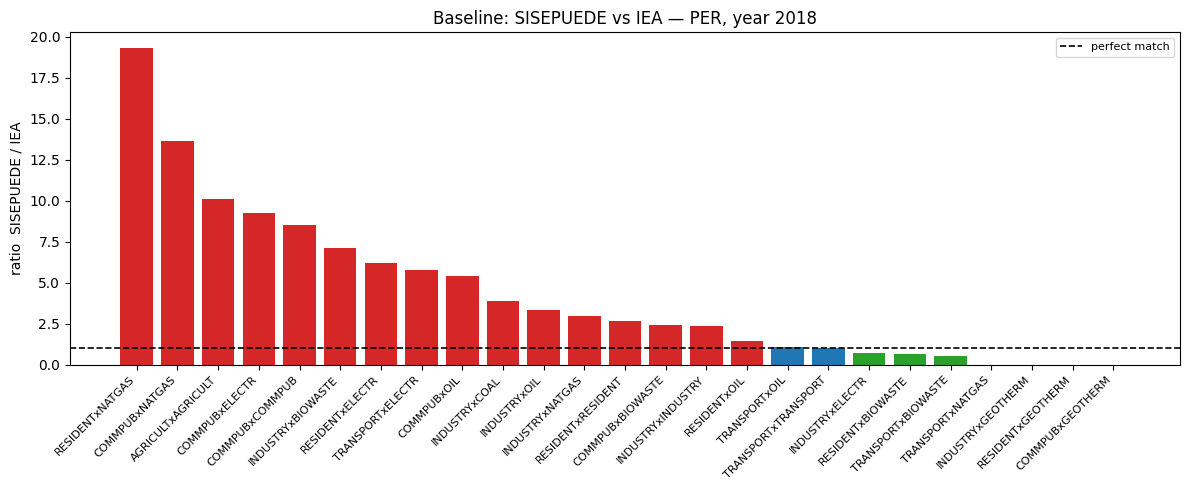

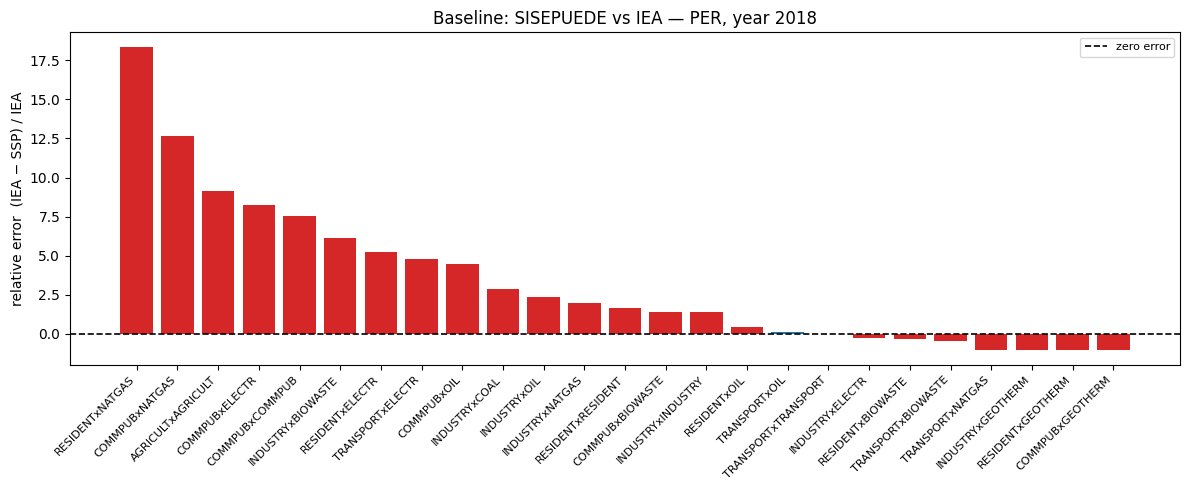

In [9]:
from sisepuede.calibration._plotting import plot_baseline_discrepancy_bar

# Bar chart of ratio (SSP / IEA) at the calibration target year
# Bars above 1 = model over-estimates; below 1 = under-estimates
plot_baseline_discrepancy_bar(
    df_comp_baseline,
    year_target=YEAR_TARGET,
    variable="ratio",
    country=ISO_COUNTRY,
)

# Same view, but as relative error  (IEA − SSP) / IEA
plot_baseline_discrepancy_bar(
    df_comp_baseline,
    year_target=YEAR_TARGET,
    variable="rel_error",
    country=ISO_COUNTRY,
)

---
## 5. Build the calibration plan

`build_energy_calibration_plan` scans all input variable names and groups them into `CalibrationGroup` objects — one group per IEA target. Each group records:
- `specs` — the input variables that are the "knobs" for this target
- `iea_targets` — the IEA `(balance_code, product_code)` pairs this group controls
- `constraint_type` — `"scalar"` (independent scaling) or `"simplex"` (fracs must sum to 1)

The plan is the same for every country — only the IEA data changes.

In [ ]:
# plan = build_energy_calibration_plan(model_attributes, only_groups=["transport__transport","resident__resident","commpub__commpub", "agricult__agricult"])
plan = build_energy_calibration_plan(model_attributes)

print(f"Total groups in plan : {len(plan)}")
print(f"  Scalar groups      : {len(plan.scalar_groups())}   (Phase 1 — sector totals)")
print(f"  Simplex groups     : {len(plan.simplex_groups())}  (Phase 2 — fuel mix)")

# Show the full plan as a table
display(plan.summary())

Total groups in plan : 57
  Scalar groups      : 36   (Phase 1 — sector totals)
  Simplex groups     : 21  (Phase 2 — fuel mix)


,name,sectors,n_specs,n_targets,constraint_type,simplex_group_ids,iea_targets,notes
0,industry__industry,inen,20,1,scalar,,INDUSTRYxINDUSTRY,Demand scalars for all non-agriculture INEN ca...
1,transport__transport,trde,3,1,scalar,,TRANSPORTxTRANSPORT,TRDE initial pkm/mtkm demands -> drive total t...
2,transport__fuel_efficiency,trns,57,0,scalar,,,"Transport fuel efficiency, average load, and o..."
3,resident__resident,scoe,2,1,scalar,,RESIDENTxRESIDENT,Initial per-household / per-GDP consumption fo...
4,commpub__commpub,scoe,2,1,scalar,,COMMPUBxCOMMPUB,Initial per-household / per-GDP consumption fo...
5,agricult__agricult,inen,1,1,scalar,,AGRICULTxAGRICULT,Initial INEN agriculture-and-livestock energy ...
6,indprod__coal,"inen, trns, scoe, enfu",46,1,scalar,,INDPRODxCOAL,All fuel-fraction inputs (inen+trns+scoe) and ...
7,indprod__oil,"inen, trns, scoe, enfu",144,1,scalar,,INDPRODxOIL,All fuel-fraction inputs (inen+trns+scoe) and ...
8,indprod__crudeoil,"inen, trns, scoe, enfu",1,1,scalar,,INDPRODxCRUDEOIL,All fuel-fraction inputs (inen+trns+scoe) and ...
9,indprod__natgas,"inen, trns, scoe, enfu",32,1,scalar,,INDPRODxNATGAS,All fuel-fraction inputs (inen+trns+scoe) and ...


In [11]:
rows = []
for group in plan:
    for spec in group.specs:
        # print(f"group: {group}\n spec: {spec}")
        rows.append({
            "group_name":      group.name,
            "constraint_type": group.constraint_type,
            "sectors":         ", ".join(group.sector),
            "iea_targets":     "; ".join(f"{b}x{p}" for b, p in group.iea_targets),
            "variable":        spec.column,
            "lb":              spec.lb,
            "ub":              spec.ub,
            "is_simplex":      spec.is_simplex_group,
            "simplex_group_id": spec.simplex_group_id,
        })

df_vars = pd.DataFrame(rows)
print(f"Total variables across all groups: {len(df_vars)}")
display(df_vars)

for group_name, grp in df_vars.groupby("group_name", sort=False):
    row = grp.iloc[0]
    # if row.constraint_type == "scalar" and any("dem" in var for var in grp['variable']):
    if row.constraint_type == "scalar":
    # if any("eff" in var for var in grp['variable']):
        print(f"\n── {group_name}  [{row['constraint_type']}]  sectors={row['sectors']}  targets={row['iea_targets']}")
        display(grp[["variable", "lb", "ub", "is_simplex", "simplex_group_id"]].reset_index(drop=True))

Total variables across all groups: 801


,group_name,constraint_type,sectors,iea_targets,variable,lb,ub,is_simplex,simplex_group_id
0,industry__industry,scalar,inen,INDUSTRYxINDUSTRY,scalar_inen_energy_demand_lime_and_carbonite,0.8,1.2,False,NaN
1,industry__industry,scalar,inen,INDUSTRYxINDUSTRY,scalar_inen_energy_demand_rubber_and_leather,0.8,1.2,False,NaN
2,industry__industry,scalar,inen,INDUSTRYxINDUSTRY,scalar_inen_energy_demand_mining,0.8,1.2,False,NaN
3,industry__industry,scalar,inen,INDUSTRYxINDUSTRY,scalar_inen_energy_demand_cement,0.8,1.2,False,NaN
4,industry__industry,scalar,inen,INDUSTRYxINDUSTRY,scalar_inen_energy_demand_wood,0.8,1.2,False,NaN
...,...,...,...,...,...,...,...,...,...
796,commpub__oil,simplex,scoe,COMMPUBxOIL,frac_scoe_heat_energy_commercial_municipal_ker...,0.8,1.2,True,87.0
797,commpub__oil,simplex,scoe,COMMPUBxOIL,frac_scoe_heat_energy_commercial_municipal_hyd...,0.8,1.2,True,87.0
798,commpub__natgas,simplex,scoe,COMMPUBxNATGAS,frac_scoe_heat_energy_commercial_municipal_nat...,0.8,1.2,True,87.0
799,commpub__electr,simplex,scoe,COMMPUBxELECTR,frac_scoe_heat_energy_commercial_municipal_ele...,0.8,1.2,True,87.0



── industry__industry  [scalar]  sectors=inen  targets=INDUSTRYxINDUSTRY


,variable,lb,ub,is_simplex,simplex_group_id
0,scalar_inen_energy_demand_lime_and_carbonite,0.8,1.2,False,NaN
1,scalar_inen_energy_demand_rubber_and_leather,0.8,1.2,False,NaN
2,scalar_inen_energy_demand_mining,0.8,1.2,False,NaN
3,scalar_inen_energy_demand_cement,0.8,1.2,False,NaN
4,scalar_inen_energy_demand_wood,0.8,1.2,False,NaN
5,scalar_inen_energy_demand_recycled_paper,0.8,1.2,False,NaN
6,scalar_inen_energy_demand_paper,0.8,1.2,False,NaN
7,scalar_inen_energy_demand_recycled_plastic,0.8,1.2,False,NaN
8,scalar_inen_energy_demand_recycled_textiles,0.8,1.2,False,NaN
9,scalar_inen_energy_demand_recycled_wood,0.8,1.2,False,NaN



── transport__transport  [scalar]  sectors=trde  targets=TRANSPORTxTRANSPORT


...

,variable,lb,ub,is_simplex,simplex_group_id
0,nemomod_entc_residual_capacity_pp_ocean_gw,0.8,1.2,False,NaN
1,nemomod_entc_frac_min_share_production_pp_ocean,0.8,1.2,False,NaN
2,nemomod_entc_total_annual_max_capacity_pp_ocea...,0.8,1.2,False,NaN
3,nemomod_entc_total_annual_min_capacity_pp_ocea...,0.8,1.2,False,NaN
4,nemomod_entc_scalar_availability_factor_pp_ocean,0.8,1.2,False,NaN



── electout__waste  [scalar]  sectors=entc  targets=ELECTOUTxWASTE


,variable,lb,ub,is_simplex,simplex_group_id
0,nemomod_entc_residual_capacity_pp_waste_incine...,0.8,1.2,False,NaN
1,nemomod_entc_frac_min_share_production_pp_wast...,0.8,1.2,False,NaN
2,nemomod_entc_total_annual_max_capacity_pp_wast...,0.8,1.2,False,NaN
3,nemomod_entc_total_annual_min_capacity_pp_wast...,0.8,1.2,False,NaN
4,nemomod_entc_scalar_availability_factor_pp_was...,0.8,1.2,False,NaN



── electout__wind  [scalar]  sectors=entc  targets=ELECTOUTxWIND


,variable,lb,ub,is_simplex,simplex_group_id
0,nemomod_entc_residual_capacity_pp_wind_gw,0.8,1.2,False,NaN
1,nemomod_entc_frac_min_share_production_pp_wind,0.8,1.2,False,NaN
2,nemomod_entc_total_annual_max_capacity_pp_wind_gw,0.8,1.2,False,NaN
3,nemomod_entc_total_annual_min_capacity_pp_wind_gw,0.8,1.2,False,NaN
4,nemomod_entc_scalar_availability_factor_pp_wind,0.8,1.2,False,NaN


In [12]:
trns_trns_calgroup = plan.filter_by_target("CRUDIMPORTS","IMPORTS")
pd.DataFrame(trns_trns_calgroup.get_specs())

,column,lb,ub,is_simplex_group,simplex_group_id
0,frac_enfu_fuel_demand_imported_pj_fuel_crude,0.8,1.2,False,None


In [ ]:
# Check which group targets have matching data in both IEA and SISEPUEDE
df_coverage = plan.coverage_report(df_comp_baseline)

n_both    = df_coverage["has_both"].sum()
n_iea     = df_coverage["has_iea_data"].sum()
n_ssp     = df_coverage["has_ssp_data"].sum()
n_total   = len(df_coverage)

print(f"Coverage ({n_total} group-target pairs):")
print(f"  Both IEA + SSP data  : {n_both}")
print(f"  IEA data only         : {n_iea - n_both}")
print(f"  SSP data only         : {n_ssp - n_both}")
print(f"  No data on either side: {n_total - n_iea - n_ssp + n_both}")
print()

# Groups that CAN be calibrated (both sides have data)
display(
    df_coverage[df_coverage["has_both"]]
    [["group_name", "sectors", "iea_balance_code", "iea_product_code", "constraint_type"]]
    .reset_index(drop=True)
)

Coverage (56 group-target pairs):
  Both IEA + SSP data  : 23
  IEA data only         : 19
  SSP data only         : 3
  No data on either side: 11



,group_name,sectors,iea_balance_code,iea_product_code,constraint_type
0,industry__industry,inen,INDUSTRY,INDUSTRY,scalar
1,transport__transport,trde,TRANSPORT,TRANSPORT,scalar
2,resident__resident,scoe,RESIDENT,RESIDENT,scalar
3,commpub__commpub,scoe,COMMPUB,COMMPUB,scalar
4,agricult__agricult,inen,AGRICULT,AGRICULT,scalar
5,transport__oil,trns,TRANSPORT,OIL,simplex
6,transport__electr,trns,TRANSPORT,ELECTR,simplex
7,transport__natgas,trns,TRANSPORT,NATGAS,simplex
8,industry__coal,inen,INDUSTRY,COAL,simplex
9,industry__oil,inen,INDUSTRY,OIL,simplex


---
## 6. Run calibration

The `Calibrator` takes the energy model, the crosswalk, the IEA data, and the reference year. Calling `.calibrate()` returns an adjusted copy of the input DataFrame — the original is never modified.

**What happens inside each iteration:**

*Phase 1 (scalar groups):*
1. Run the model once on the current inputs.
2. For each scalar group: `scalar = iea_target_pj / model_current_pj`. Apply to all input columns in the group.
3. Skip groups whose columns contain `frac_*` variables (those are simplex-constrained and handled in Phase 2).

*Phase 2 (simplex groups):*
1. Run the model once on the Phase-1-adjusted inputs.
2. For each simplex group: `scale = (iea_fuel_tj / iea_sector_total_tj) / (model_fuel_pj / model_sector_pj)`. Apply to all `frac_*` columns in the group.
3. Aitchison renormalization forces fracs to sum to 1 within each category.

In [14]:
# Pre-calibration sanity check

# 1. No NaN values anywhere
total_nans = df_input_energy.isna().sum().sum()
assert total_nans == 0, f"df_input_energy still has {total_nans} NaN values"
print(f"No NaN values in df_input_energy ({df_input_energy.shape})")

# 2. frac_trns_fuelmix sums <= 1 for every category group
frac_cols = [c for c in df_input_energy.columns if c.startswith("frac_trns_fuelmix_")]
prefixes  = sorted(set(c.rsplit("_", 1)[0] for c in frac_cols))
worst_sum = 0.0
for prefix in prefixes:
    cols  = [c for c in frac_cols if c.startswith(prefix + "_")]
    worst = df_input_energy[cols].sum(axis=1).max()
    if worst > worst_sum:
        worst_sum = worst
assert worst_sum <= 1 + 1e-6, f"Frac sums exceed threshold: max={worst_sum:.8f}"
print(f"All frac_trns_fuelmix groups sum ≤ 1  (max={worst_sum:.8f})")

# 3. Test with .copy() — exactly what calibrate() passes to _run_model
print("\nTesting model with df_input_energy.copy() (mirrors what the calibrator does)...",
      end=" ", flush=True)
_ = model_energycon.project(df_input_energy.copy())
print("ok")

# 4. Check frac sums in the copy after project() returns
#    (project() may modify the frame internally via model_socioeconomic)
df_copy_test = df_input_energy.copy()
_ = model_energycon.project(df_copy_test)
frac_sums_after = pd.Series({
    prefix: df_copy_test[[c for c in frac_cols if c.startswith(prefix + "_")]].sum(axis=1).max()
    for prefix in prefixes
})
worst_after = frac_sums_after.max()
print(f"\nAfter project() call, max frac sum in df_copy_test: {worst_after:.8f}")
if worst_after > 1 + 1e-6:
    print("  WARNING: project() mutated the copy — fracs now exceed 1!")
    print(frac_sums_after[frac_sums_after > 1 + 1e-6])
else:
    print("  Fracs unchanged / still within tolerance in the copy")

No NaN values in df_input_energy ((8, 3075))
All frac_trns_fuelmix groups sum ≤ 1  (max=1.00000000)

Testing model with df_input_energy.copy() (mirrors what the calibrator does)... ok

After project() call, max frac sum in df_copy_test: 1.00000000
  Fracs unchanged / still within tolerance in the copy


In [15]:
calibrator = Calibrator(
    models                    = model_energycon,
    crosswalk                 = xw,
    df_iea_long               = df_iea_raw,
    year_target               = YEAR_TARGET,
    include_energy_production = False,
)

# calibrate() returns:
#   df_calibrated — a copy of df_input_energy with adjusted consumpinit_* and frac_*
#   log           — per-iteration, per-group record of scalars applied and status
df_calibrated, log = calibrator.calibrate(
    df_in  = df_input_energy,
    plan   = plan,
    n_iter = N_ITER,
    option = N_OPT,
    enforce_varspec_bounds = False,
)


=== Calibration iteration 1/2 ===
  Phase 1 — sector totals (consumpinit_*, scalar_*, efficiencies):
    Running model (Phase 1 baseline)... done
    applied=5  skipped=31
  Phase 2 (v2) — fuel mix via QP:
    Running model (Phase 2 baseline, QP)... done
    Solving QP: m=18 targets, n=253 fracs, 31 simplex groups, gamma=100.0...
    applied=193  skipped=55

=== Calibration iteration 2/2 ===
  Phase 1 — sector totals (consumpinit_*, scalar_*, efficiencies):
    Running model (Phase 1 baseline)... done
    applied=5  skipped=31
  Phase 2 (v2) — fuel mix via QP:
    Running model (Phase 2 baseline, QP)... done
    Solving QP: m=18 targets, n=253 fracs, 31 simplex groups, gamma=100.0...
    applied=193  skipped=55


In [16]:
# Inspect the calibration log — what scalar was applied to each group?
df_log = calibrator.log_summary(log)

print(f"Log entries: {len(df_log)}")

if N_OPT == 0 or N_OPT == 1:
    print(f"\nPhase 1 results (sector totals):")
    display(
        df_log[df_log["phase"] == 1]
        [["iteration", "group", "status", "target", "current", "target_val", "scalar"]]
        .reset_index(drop=True)
    )

elif N_OPT == 0 or N_OPT == 2:
    print(f"\nPhase 2 results (fuel mix):")
    display(
        df_log[df_log["phase"] == 2]
        [["iteration", "group", "status", "target", "current", "target_val", "scalar"]]
        .reset_index(drop=True)
    )

Log entries: 588


---
## 7. Post-calibration evaluation

Run the model on the calibrated inputs and rebuild the comparison table. Then compare summary statistics before and after.

In [ ]:
print("Running model on calibrated inputs...", end=" ", flush=True)
df_out_calibrated = model_energycon(df_calibrated)
df_out_calibrated = df_out_calibrated.merge(
    df_calibrated[["time_period", "year"]].drop_duplicates(),
    on="time_period", how="left",
)
print("done")

df_ssp_calibrated = xw.aggregate_sisepuede(df_out_calibrated, col_year="year")
df_comp_calibrated = xw.build_comparison(
    df_ssp_calibrated, df_iea_raw,
    year_min=START_YEAR, year_max=IEA_YEAR_LIMIT,
)

Running model on calibrated inputs... done


In [26]:
# Before/after summary table at YEAR_TARGET
def _ratio_at_year(df_comp, year):
    return (
        df_comp[df_comp["year"] == year]
        .groupby(["iea_balance_code", "iea_product_code"])
        ["ratio"]
        .mean()
    )

def _error_at_year(df_comp, year):
    return (
        df_comp[df_comp["year"] == year]
        .groupby(["iea_balance_code", "iea_product_code"])
        ["rel_err"]
        .mean()
    )

ratio_before = _ratio_at_year(df_comp_baseline,  YEAR_TARGET).rename("ratio_before")
ratio_after  = _ratio_at_year(df_comp_calibrated, YEAR_TARGET).rename("ratio_after")
error_before = _error_at_year(df_comp_baseline,  YEAR_TARGET).rename("error_before")
error_after  = _error_at_year(df_comp_calibrated, YEAR_TARGET).rename("error_after")

df_compare = pd.concat([ratio_before, ratio_after, error_before, error_after], axis=1).dropna(how="all")
df_compare["improved_ratio"] = (
    (df_compare["ratio_after"] - 1).abs() < (df_compare["ratio_before"] - 1).abs()
)
df_compare["improved_error"] = (
    (df_compare["error_after"]).abs() < (df_compare["error_before"]).abs()
)

n_improved_ratio = df_compare["improved_ratio"].sum()
n_improved_error = df_compare["improved_error"].sum()
n_total_ratio = df_compare["improved_ratio"].notna().sum()
n_total_error = df_compare["improved_error"].notna().sum()
print(f"Targets ratio improved: {n_improved_ratio}/{n_total_ratio}  (ratio closer to 1.0 after calibration)")
print(f"Targets error improved: {n_improved_error}/{n_total_error}  (error closer to 0 after calibration)")
print(f"Year: {YEAR_TARGET}")
display(df_compare.sort_values("ratio_before", ascending=False))

Targets ratio improved: 18/26  (ratio closer to 1.0 after calibration)
Targets error improved: 18/26  (error closer to 0 after calibration)
Year: 2018


ratio_before  ratio_after  error_before  \
iea_balance_code iea_product_code                                            
COMMPUB          COAL                       inf          inf           inf   
RESIDENT         NATGAS               19.318726     4.755988     18.318726   
COMMPUB          NATGAS               13.625580     0.940713     12.625580   
AGRICULT         AGRICULT             10.114147     1.000000      9.114147   
COMMPUB          ELECTR                9.241447     1.082506      8.241447   
                 COMMPUB               8.532706     1.000000      7.532706   
INDUSTRY         BIOWASTE              7.144486     2.770878      6.144486   
RESIDENT         ELECTR                6.226009     2.384412      5.226009   
TRANSPORT        ELECTR                5.762808     5.906763      4.762808   
COMMPUB          OIL                   5.439776     0.898591      4.439776   
INDUSTRY         COAL                  3.882430     1.811456      2.882430   
                 OIL                   3.350713     1.157965      2.350713   
                 NATGAS                2.970907     1.165945      1.970907   
RESIDENT         RESIDENT              2.643970     1.000000      1.643970   
COMMPUB          BIOWASTE              2.400826     0.543235      1.400826   
INDUSTRY         INDUSTRY              2.388509     1.000171      1.388509   
RESIDENT         OIL                   1.453753     0.910661      0.453753   
TRANSPORT        OIL                   1.099439     1.112677      0.099439   
                 TRANSPORT             0.988013     0.999747     -0.011987   
INDUSTRY         ELECTR                0.720076     0.268896     -0.279924   
RESIDENT         BIOWASTE              0.648095     0.226267     -0.351905   
TRANSPORT        BIOWASTE              0.558047     0.559707     -0.441953   
                 NATGAS                0.000069     0.000073     -0.999931   
INDUSTRY         GEOTHERM              0.000000     0.000000     -1.000000   
RESIDENT         GEOTHERM              0.000000     0.000000     -1.000000   
COMMPUB          GEOTHERM              0.000000     0.000000     -1.000000   

                                    error_after  improved_ratio  \
iea_balance_code iea_product_code                                 
COMMPUB          COAL                       inf           False   
RESIDENT         NATGAS            3.755988e+00            True   
COMMPUB          NATGAS           -5.928660e-02            True   
AGRICULT         AGRICULT         -1.413137e-16            True   
COMMPUB          ELECTR            8.250624e-02            True   
                 COMMPUB           2.517458e-16            True   
INDUSTRY         BIOWASTE          1.770878e+00            True   
RESIDENT         ELECTR            1.384412e+00            True   
TRANSPORT        ELECTR            4.906763e+00           False   
COMMPUB          OIL              -1.014093e-01            True   
INDUSTRY         COAL              8.114562e-01            True   
                 OIL               1.579645e-01            True   
                 NATGAS            1.659448e-01            True   
RESIDENT         RESIDENT          1.763313e-16            True   
COMMPUB          BIOWASTE         -4.567651e-01            True   
INDUSTRY         INDUSTRY          1.706759e-04            True   
RESIDENT         OIL              -8.933903e-02            True   
TRANSPORT        OIL               1.126774e-01           False   
                 TRANSPORT        -2.525772e-04            True   
INDUSTRY         ELECTR           -7.311044e-01           False   
RESIDENT         BIOWASTE         -7.737327e-01           False   
TRANSPORT        BIOWASTE         -4.402931e-01            True   
                 NATGAS           -9.999266e-01            True   
INDUSTRY         GEOTHERM         -1.000000e+00           False   
RESIDENT         GEOTHERM         -1.000000e+00           False   
COMMPUB          GEOTHERM         -1.0000

### 7.2 Visualizations

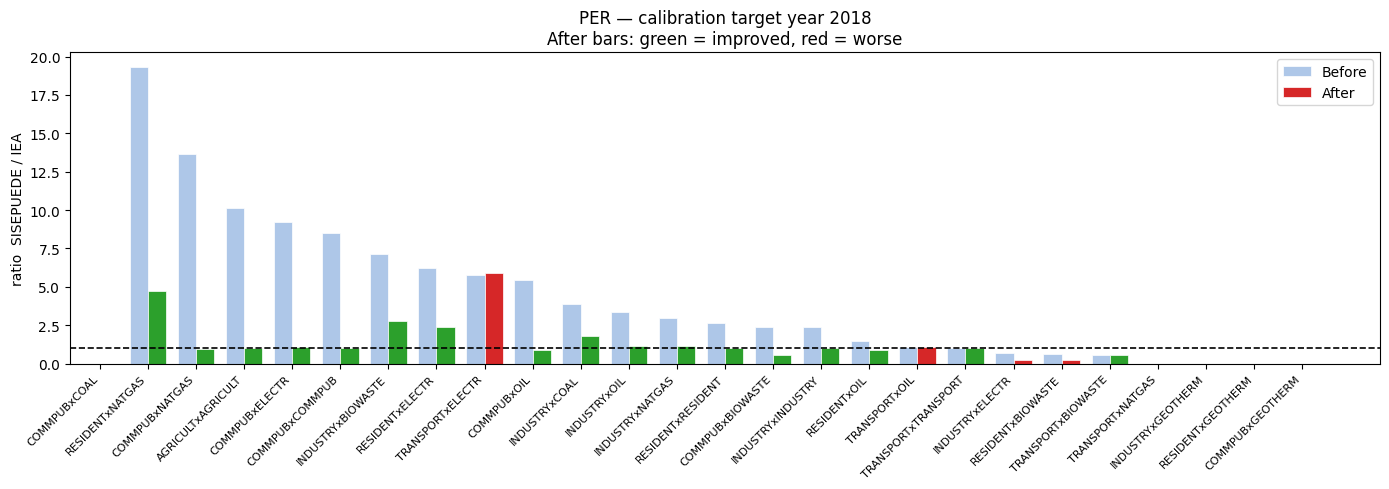

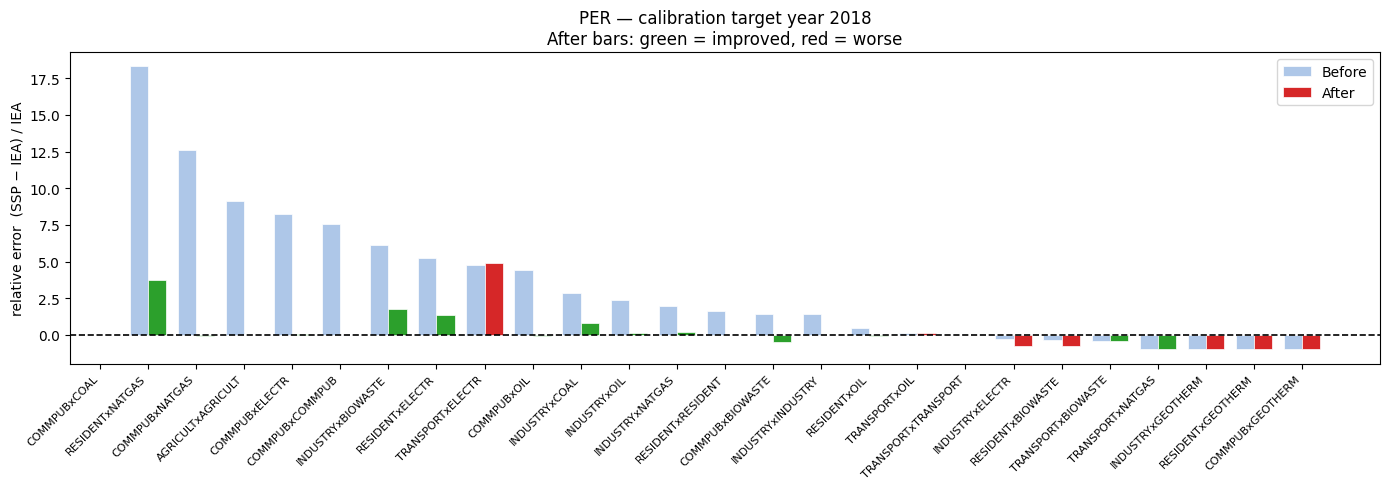

In [19]:
from sisepuede.calibration._plotting import plot_before_after_discrepancy_bar

# Ratio view (reference line at 1.0)
plot_before_after_discrepancy_bar(
    df_comp_baseline,
    df_comp_calibrated,
    year_target=YEAR_TARGET,
    variable="ratio",
    country=ISO_COUNTRY,
)

# Relative-error view (reference line at 0.0)
plot_before_after_discrepancy_bar(
    df_comp_baseline,
    df_comp_calibrated,
    year_target=YEAR_TARGET,
    variable="rel_error",
    country=ISO_COUNTRY,
)

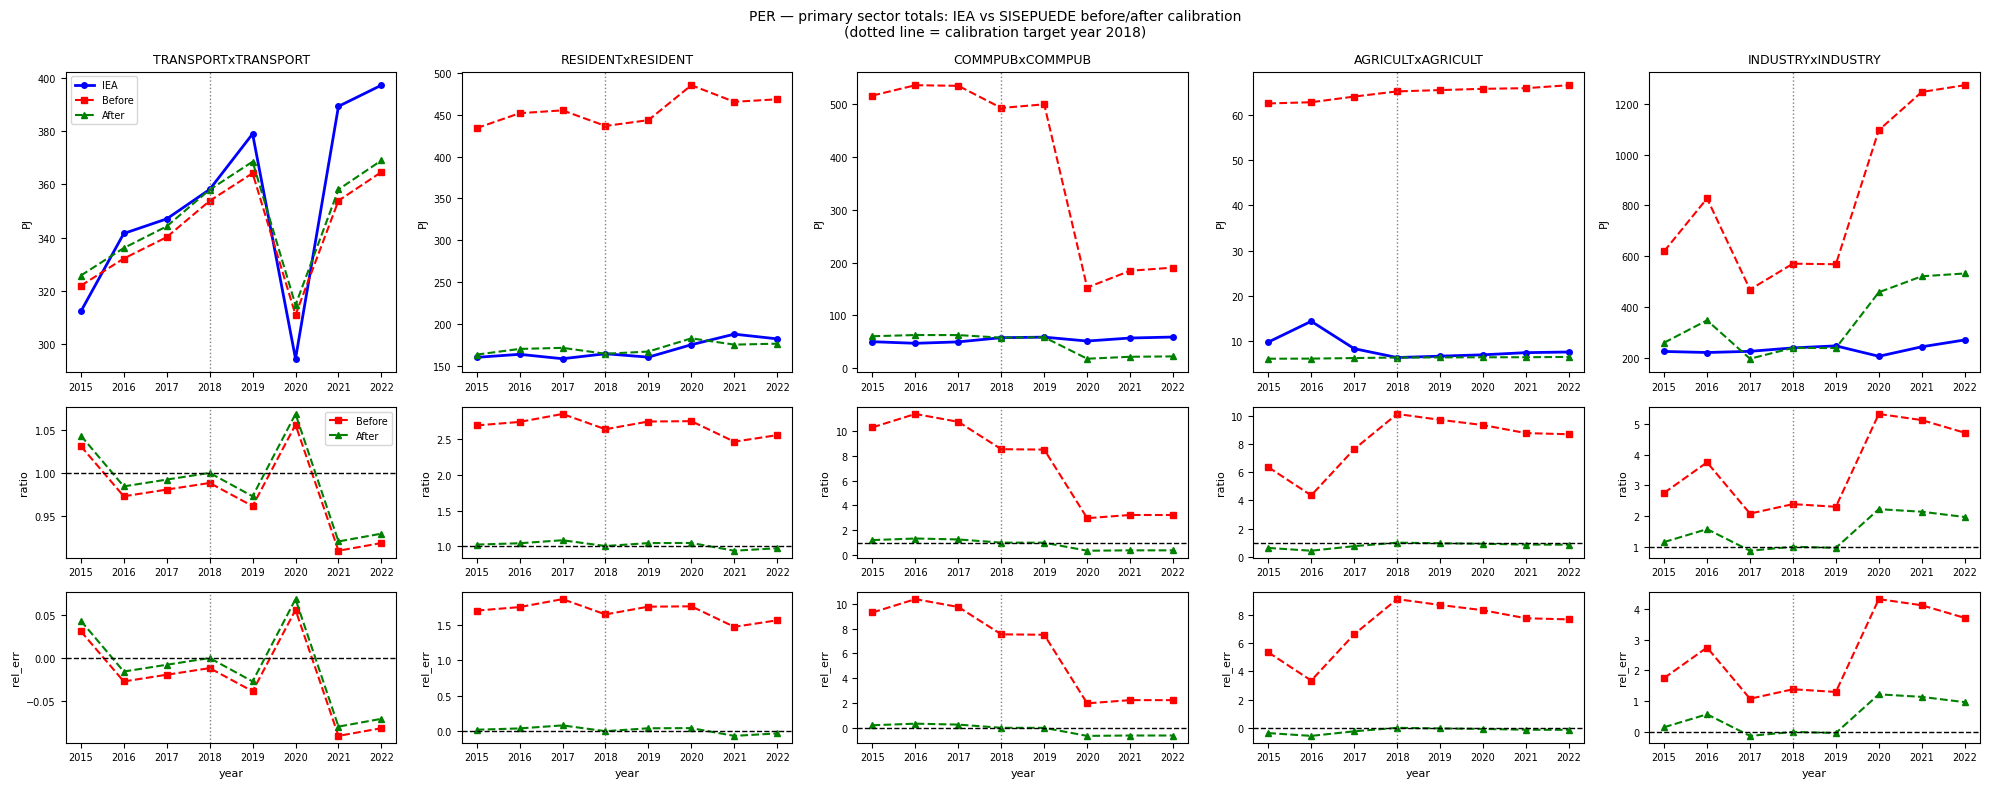

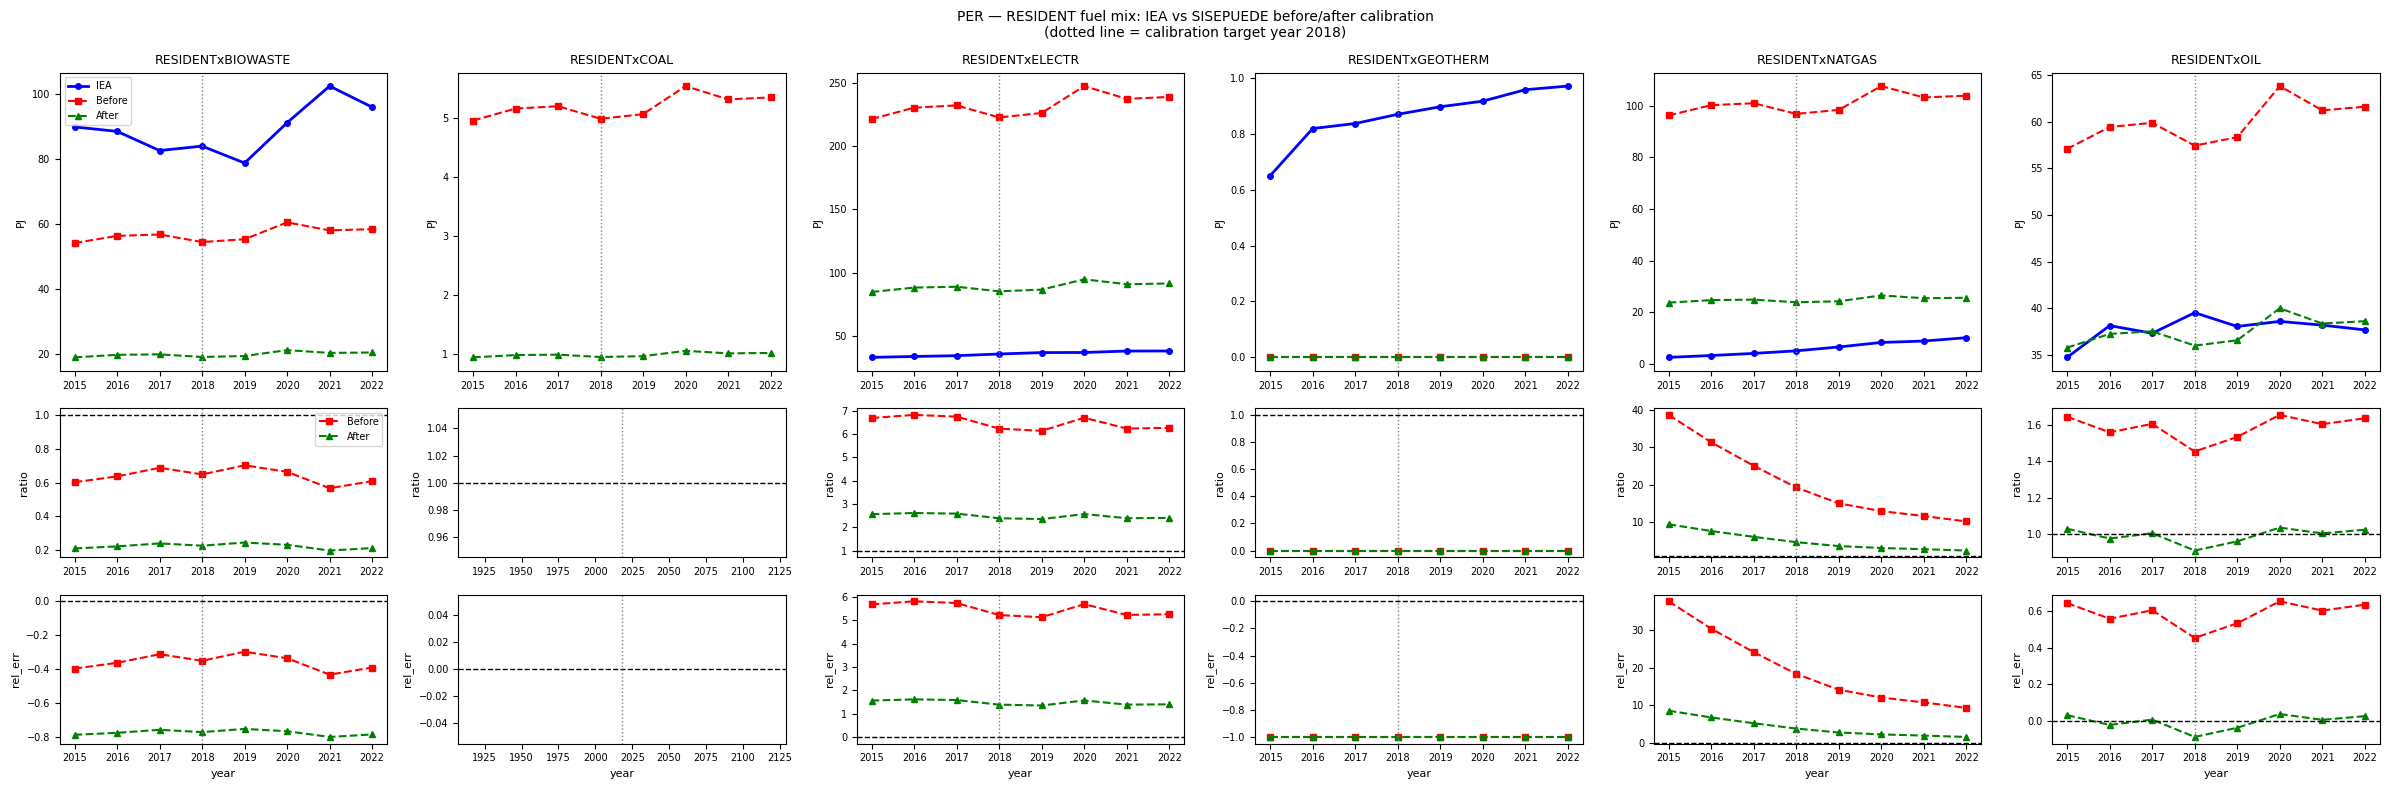

In [ ]:
from sisepuede.calibration._plotting import plot_before_after_time_series

# Primary sector totals (Phase 1 targets)
plot_before_after_time_series(
    df_comp_baseline,
    df_comp_calibrated,
    year_target=YEAR_TARGET,
    mode="primary",
    country=ISO_COUNTRY,
)

# All fuels within a specific sector (Phase 2 targets)
plot_before_after_time_series(
    df_comp_baseline,
    df_comp_calibrated,
    year_target=YEAR_TARGET,
    mode="fuel_mix",
    sector="RESIDENT",
    country=ISO_COUNTRY,
    with_diagnostics=True,
)

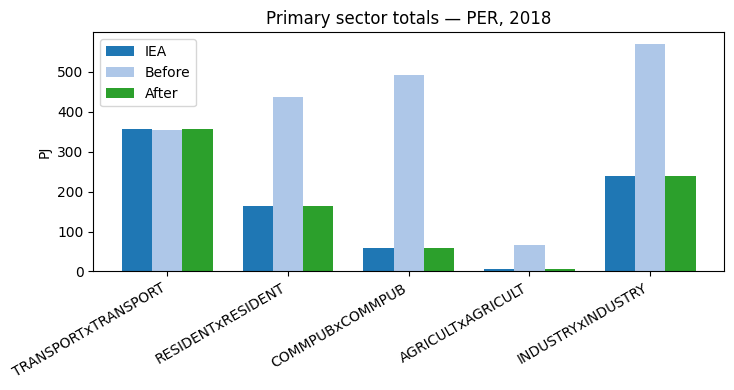

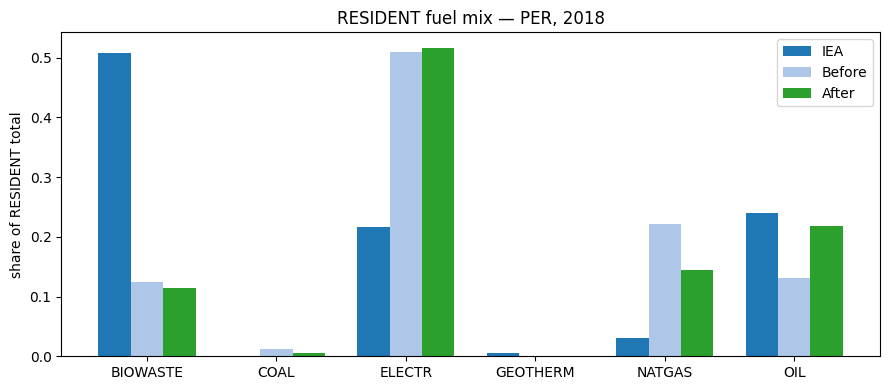

In [21]:
from sisepuede.calibration._plotting import plot_before_after_bar

# Primary sector totals — absolute values (PJ) at YEAR_TARGET
plot_before_after_bar(
    df_comp_baseline,
    df_comp_calibrated,
    year_target=YEAR_TARGET,
    mode="primary",
    country=ISO_COUNTRY,
)

# Fuel-mix shares within a specific sector at YEAR_TARGET
plot_before_after_bar(
    df_comp_baseline,
    df_comp_calibrated,
    year_target=YEAR_TARGET,
    mode="fuel_mix",
    sector="RESIDENT",
    country=ISO_COUNTRY,
)

### 7.3 Summary tables

---
## 8. Save calibrated inputs

The calibrated DataFrame is `df_calibrated`. It contains the same columns as `df_input_energy` but with adjusted `consumpinit_*` and `frac_*` values.

For downstream use (e.g., feeding into a full SISEPUEDE run), extract only the original input columns — strip out the AFOLU/IPPU output columns that were merged in.

In [22]:
# Extract only the original input columns (drop AFOLU/IPPU output columns)
original_input_cols = df_input.columns.tolist()
input_cols_in_calibrated = [c for c in original_input_cols if c in df_calibrated.columns]

df_calibrated_inputs = df_calibrated[input_cols_in_calibrated].copy()

out_path = f"{PATH_OUTPUT_DIR}/input_data_{ISO_COUNTRY.lower()}_calibrated_{YEAR_TARGET}.csv"
df_calibrated_inputs.to_csv(out_path, index=False)
print(f"Saved: {out_path}")
print(f"Shape: {df_calibrated_inputs.shape}")

Saved: /Users/dianamendez/sisepuede-data/input_data_per_calibrated_2018.csv
Shape: (8, 2420)


In [23]:
# Which input columns actually changed (and by how much)?
changed = []
for col in input_cols_in_calibrated:
    orig = df_input_energy[col].values if col in df_input_energy.columns else None
    new  = df_calibrated[col].values
    if orig is None:
        continue
    if not np.issubdtype(df_calibrated[col].dtype, np.number):
        continue
    if not np.allclose(orig, new, equal_nan=True):
        ratio = np.nanmean(new / np.where(orig == 0, np.nan, orig))
        changed.append({"column": col, "mean_scale_applied": round(ratio, 4)})

df_changed = pd.DataFrame(changed)
df_changed.to_csv(f"{PATH_OUTPUT_DIR}/calibrated_columns_{ISO_COUNTRY.lower()}_{YEAR_TARGET}.csv", index=False)
print(f"{len(df_changed)} input columns were adjusted during calibration:")
display(df_changed)

253 input columns were adjusted during calibration:


,column,mean_scale_applied
0,frac_inen_energy_cement_coal,0.9952
1,frac_inen_energy_chemicals_coal,1.4141
2,frac_inen_energy_electronics_coal,1.6798
3,frac_inen_energy_glass_coal,0.9958
4,frac_inen_energy_lime_and_carbonite_coal,0.9956
...,...,...
248,scalar_inen_energy_demand_recycled_textiles,0.4186
249,scalar_inen_energy_demand_recycled_wood,0.4186
250,scalar_inen_energy_demand_rubber_and_leather,0.4186
251,scalar_inen_energy_demand_textiles,0.4186


---
## Notes and next steps

### What the calibrator does and does not do

| Does | Does NOT |
|--------|------------|
| Match sector totals to IEA at `year_target` | Fit a time series (only one year is targeted) |
| Match fuel-mix shares to IEA at `year_target` | Handle targets with zero model output (can't scale from zero) |
| Preserve simplex constraint (frac sum = 1) | Guarantee convergence if IEA data is internally inconsistent |
| Preserve relative category breakdown (cement vs metals, etc.) | Calibrate ENTC/electricity-supply variables (requires Julia back-end) |

### If residual error is still large after 2 iterations

Possible causes and fixes:
1. **Calibration target not covered by crosswalk** — check `df_coverage` for groups with `has_both=False`.
2. **Fuel absent in model but present in IEA** — the calibrator skips these (`skipped_zero_current_share` in log). We'd need to set a non-zero baseline fraction for that fuel in the input file first.
3. **IEA data inconsistency** — fuel subtotals don't add up to the sector total. Check `df_iea_raw` for the relevant `(balance, product)` pairs.
4. **Try `n_iter=3`** —  a third iteration could close residual coupling.

### Sensitivity analysis before calibration

To make sure which variables matter most, we could run an OAT sensitivity sweep first using `SensitivityRunner` (see `sensitivity_analysis_example.ipynb`). The Spearman scores will tell us which inputs have the most leverage on which IEA targets, which can guide tightening the calibration plan.